# Light model

                              ┌──────────────────────────────┐
                              │        LightPlane            │
                              │   (AbstractLight, redshift)  │
                              └──────────────┬───────────────┘
                                             │ wraps
                                             ▼
                              ┌──────────────────────────────┐
                              │        AbstractLight         │
                              │  (abstract type, LightModel) │
                              └──────────────┬───────────────┘
                               △             △              △
                 ┌─────────────┴───┐ ┌───────┴──────┐ ┌─────┴──────────────┐
                 │  ExtendedSource │ │  PointImage  │ │   CompositeImage   │
                 │  {F, P}         │ │  {Tuple}     │ │   {Tuple}          │
                 │  profile::F     │ │  flux::F64   │ │                    │
                 │  params::P      │ │ beta_x,beta_y│ │                    │
                 └────────┬────────┘ └──────┬───────┘ └─────┬──────────────┘
                          │                 │               │
                          └─────────────────┴───────────────┘
                                            │ wraps
                                            ▼
                            ┌──────────────────────────────┐
                            │    RAW PROFILE FUNCTIONS     │
                            │  (plain Julia Functions)     │
                            │                              │
                            │  SersicSpheric  (n any)      │ 
                            │  SersicElliptical            │ 
                            │  GaussianSphere (n=0.5)      │  
                            │  ExponentialSpheric (n=1)    │ 
                            │  ExponentialElliptical       |
                            └──────────────────────────────┘

In [1]:
# including packages
using LazyGrids, PyPlot, BenchmarkTools
using PSFModels, ImageFiltering
using PyPlot

In [2]:
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots

In [3]:
x = range(-2, 2, 51)
xg, yg = LazyGrids.ndgrid(x,x)

([-2.0 -2.0 … -2.0 -2.0; -1.92 -1.92 … -1.92 -1.92; … ; 1.92 1.92 … 1.92 1.92; 2.0 2.0 … 2.0 2.0], [-2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0; … ; -2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0])

# Gaussian

In [4]:
using Jens.LightModel:GaussianLight as GaussianLight

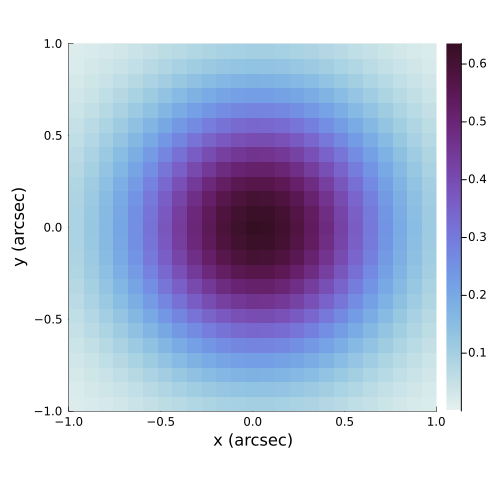

In [5]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.5,
                :xcentre=>0.03, :ycentre=>0.0)
# Gaussian Light Profile
SourceLight = GaussianLight.GaussianSphere(xg, yg; LightParaDict...);

gc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc, xg, yg, SourceLight)
display(gc)

# Elliptical Gaussian

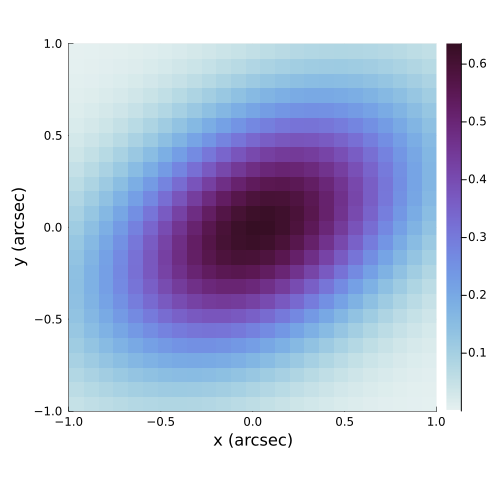

In [6]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.5, :e1=>0.1, :e2=>0.2,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = GaussianLight.GaussianEllipse(xg, yg; LightParaDict...);
gc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc, xg, yg, SourceLight)
display(gc)

# Exponential spherical

In [7]:
using Jens.LightModel:ExponentialLight as ExponentialLight

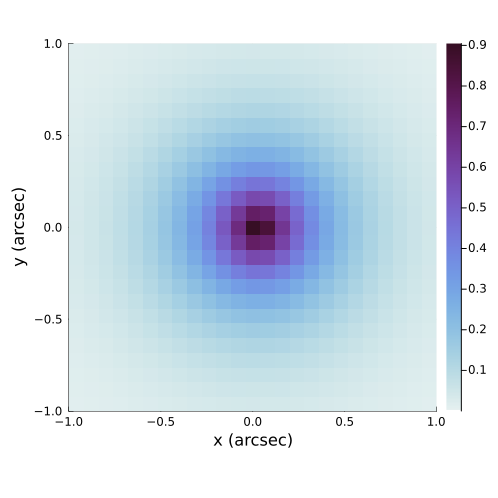

In [8]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>0.5,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = ExponentialLight.ExponentialSpheric(xg, yg; LightParaDict...);

gc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc, xg, yg, SourceLight)
display(gc)

# Exponential Elliptical

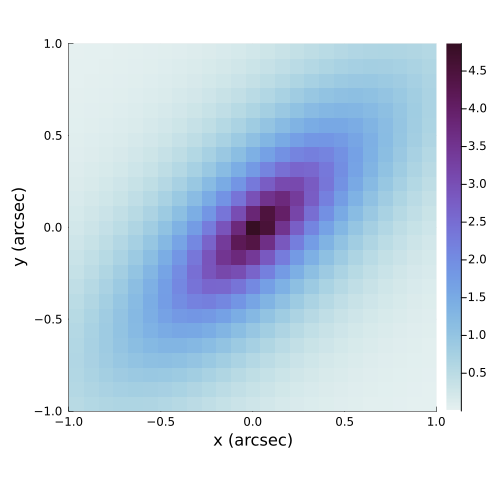

In [9]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>1., :q=>0.6,:varphi=>pi/4,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = ExponentialLight.ExponentialElliptical(xg, yg; LightParaDict...);

gc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc, xg, yg, SourceLight)
display(gc)

# Sersic sepherical

In [10]:
using Jens.LightModel:SersicLight as SersicLight

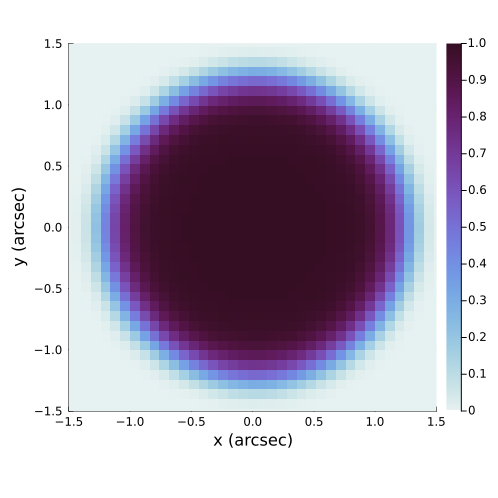

In [11]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>0.5, :n=>0.1,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = SersicLight.SersicSpheric(xg, yg; LightParaDict...);


gc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc, xg, yg, SourceLight)
display(gc)

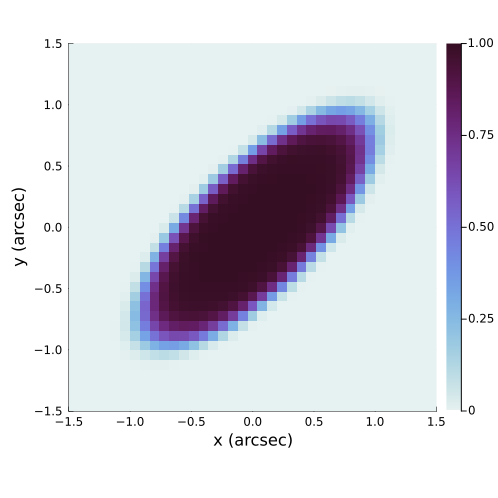

In [12]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>0.5, :n=>0.1,:q=>0.6,:varphi=>pi/4,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = SersicLight.SersicElliptical(xg, yg; LightParaDict...);

gc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc, xg, yg, SourceLight)
display(gc)

# Point Source

In [13]:
using Jens
using Jens:LensPSF as PSF
using Jens:LensModel as LM
using Jens.LensModel:ComLens as ComLens

In [14]:
lens = ComLens.CombinedLens(
    LM.SIS   => (theta_E=1.0, xcentre=0.0, ycentre=0.0),
    LM.Shear => (gamma1=0.05, gamma2=0.03),
)

grid = LG.GenGrid(pix_n=51, pix_size=0.1)

# PS
pt = Jens.LightModel.PointImage(flux=10.0, beta_x=0.0, beta_y=0.0)

img = LG.render_lens(pt, grid, lens;
    psf    = PSF.GaussianPSF(fwhm=0.2),  
    half   = 11,                              # PSF kernel 半径
    method = :shift,
    #method = :supersample,                   
    #n_sub  = 5,                              # combined with supersample method
    z_source = 1.5);           

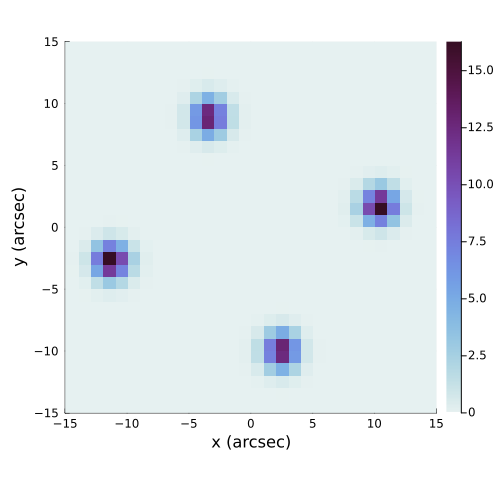

In [15]:
gc = Jplots.LensCanvas(;  xlims=(-15,15), ylims=(-15,15),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc,img)
display(gc)

# Composite image

In [16]:
host = LightModel.ExtendedSource(SersicLight.SersicSpheric; amp=15.0, Rsersic=1., n=1.0)
agn  = LightModel.PointImage(flux=10, beta_x=0., beta_y=0.0)
# the flux is only for reference, to enhence the image

src = LensGenerator.LightPlane(
    LightModel.CompositeImage(host, agn),
    z=1.,
)

Jens.LensGenerator.LightPlane{Jens.LightModel.CompositeImage{Tuple{Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.SersicLight.SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64}}, Jens.LightModel.PointImage}}}(Jens.LightModel.CompositeImage{Tuple{Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.SersicLight.SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64}}, Jens.LightModel.PointImage}}((Jens.LightModel.ExtendedSource{typeof(Jens.LightModel.SersicLight.SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 15.0, Rsersic = 1.0, n = 1.0)), Jens.LightModel.PointImage(10.0, 0.0, 0.0))), 1.0)

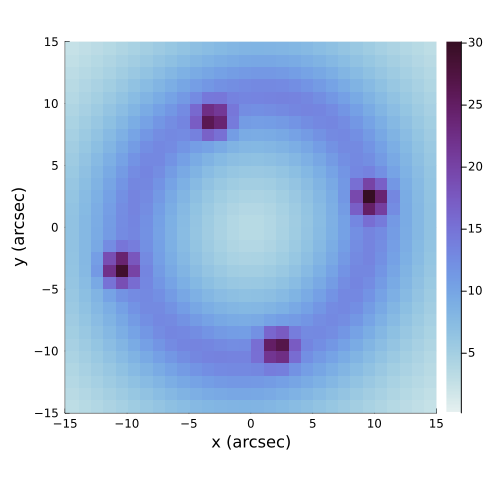

In [17]:
grid = LG.GenGrid(pix_n=51, pix_size=0.1)
img = LensGenerator.render_lens(src.light, grid, lens; 
            z_source=src.z, psf = PSF.GaussianPSF(fwhm=0.2), )
gc = Jplots.LensCanvas(;  xlims=(-15,15), ylims=(-15,15),
            size=(500,500))
SourcePlane = Jplots.PlotPlane!(gc,img)
display(gc)